In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from preprocess import transcriptions

In [17]:
textes_annotes = pd.read_json("outputs/predictions_tot.jsonl", lines=True)

In [18]:
textes_annotes = textes_annotes.merge(transcriptions[["id", "parti_synthetique"]], on = "id", how="left")
textes_annotes.head()

,id,text,annotations,parti_synthetique
0,EL196_L_1993_03_076_12_1_PF_01,Département de Seine-Maritime - 12ème Circonsc...,"[{'word': 'Département', 'label': 'O', 'score'...",Sans étiquette / Divers
1,EL190_L_1993_03_024_02_1_PF_03,ELECTIONS LEGISLATIVES DU 21 MARS 1993 REPUBLI...,"[{'word': 'ELECTIONS', 'label': 'O', 'score': ...",Sans étiquette / Divers
2,EL190_L_1993_03_017_01_1_PF_07,ELECTIONS LEGISLATIVES MARS 1993 Votre candida...,"[{'word': 'ELECTIONS', 'label': 'O', 'score': ...",Autre / Non classé
3,EL192_L_1993_03_050_02_1_PF_03,ENTENTE DES ECOLOGISTES Elections Législatives...,"[{'word': 'ENTENTE', 'label': 'O', 'score': 0....",Ecologiste
4,EL196_L_1993_03_079_04_1_PF_03,Les Verts Confédération Écologiste - Parti Éco...,"[{'word': 'Les', 'label': 'O', 'score': 0.7723...",Ecologiste


In [ ]:
import ast
def parse_annotations(val):
    """Accepte une liste Python ou une chaîne repr d'une liste."""
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except Exception:
            return []
    return []

textes_annotes["annotations"] = textes_annotes["annotations"].apply(parse_annotations)

In [ ]:

ENTITY_TYPES = ["SUJ", "VERB_CONCRET", "VERB_CONTEXTE", "OBJ"]   

def extract_entities(annotations, entities_list):
    """
    Renvoie un dict {type_entité: [liste de mots]} pour les tokens B-*.
    On ne garde que les débuts d'entités (B-) pour éviter de double-compter.
    """
    entities = {t: [] for t in entities_list}
    for tok in annotations:
        label = tok.get("label", "O")
        word  = tok.get("word", "")
        if label.startswith("B-"):
            etype = label[2:]
            if etype in entities:
                entities[etype].append(word)
    return entities
 
 
textes_annotes["entities"] = textes_annotes["annotations"].apply(extract_entities, args = [ENTITY_TYPES])

In [25]:
for etype in ENTITY_TYPES:
    textes_annotes[f"n_{etype}"] = textes_annotes["entities"].apply(lambda e: len(e[etype]))
 
textes_annotes["n_tokens_total"] = textes_annotes["annotations"].apply(len)
textes_annotes["n_entities_total"] = textes_annotes[[f"n_{t}" for t in ENTITY_TYPES]].sum(axis=1)

In [46]:
count_cols = [f"n_{t}" for t in ENTITY_TYPES] + ["n_tokens_total", "n_entities_total"]
ordre_partis = ['Autre / Non classé','Sans étiquette / Divers','Extrême-Gauche', 'Parti socialiste - Gauche', 'Ecologiste',
'Centre', 'UDF/RPR', 'Extrême-Droite', 'Régionaliste']
 
stats = (
    textes_annotes.groupby("parti_synthetique")[count_cols]
    .agg(["sum", "mean", "median", "std"])
)
stats =stats.reset_index()
stats['parti_synthetique'] = pd.Categorical(
    stats['parti_synthetique'], 
    categories=ordre_partis, 
    ordered=True)
stats = stats.sort_values('parti_synthetique')

stats.columns = ["_".join(c) for c in stats.columns]
stats = stats.rename(columns={f"n_tokens_total_count": "n_docs"})

for etype in ENTITY_TYPES:
    stats[f"freq_{etype}"] = (
        stats[f"n_{etype}_sum"] / stats["n_tokens_total_sum"] * 100
    ).round(2)
stats["n_VERB_sum"]=stats["n_VERB_CONCRET_sum"]+stats["n_VERB_CONTEXTE_sum"]
stats["part_VERB_CONCRET"] = stats["n_VERB_CONCRET_sum"]/stats["n_VERB_sum"]
stats["part_VERB_CONTEXTE"] = stats["n_VERB_CONTEXTE_sum"]/stats["n_VERB_sum"]
stats.head()

,parti_synthetique_,n_SUJ_sum,n_SUJ_mean,n_SUJ_median,n_SUJ_std,n_VERB_CONCRET_sum,n_VERB_CONCRET_mean,n_VERB_CONCRET_median,n_VERB_CONCRET_std,n_VERB_CONTEXTE_sum,...,n_entities_total_mean,n_entities_total_median,n_entities_total_std,freq_SUJ,freq_VERB_CONCRET,freq_VERB_CONTEXTE,freq_OBJ,n_VERB_sum,part_VERB_CONCRET,part_VERB_CONTEXTE
0,Autre / Non classé,1670,5.457516,5.0,5.727113,1866,6.098039,5.0,6.358435,2006,...,20.683007,17.0,19.508573,0.76,0.85,0.91,0.36,3872,0.481921,0.518079
7,Sans étiquette / Divers,8105,6.520515,6.0,4.890938,9263,7.452132,6.0,5.972690,9206,...,24.326629,22.0,14.516396,1.15,1.31,1.30,0.52,18469,0.501543,0.498457
4,Extrême-Gauche,8216,8.630252,7.0,6.430396,10476,11.004202,10.0,6.551582,11139,...,38.775210,30.0,24.914404,0.99,1.26,1.34,0.85,21615,0.484663,0.515337
5,Parti socialiste - Gauche,4056,8.432432,7.0,5.325656,4552,9.463617,8.0,6.436810,4149,...,29.503119,27.0,15.562257,1.27,1.42,1.29,0.45,8701,0.523158,0.476842
2,Ecologiste,3180,2.933579,1.0,3.337470,6459,5.958487,5.0,4.776939,3895,...,13.404059,9.0,10.405048,0.63,1.27,0.77,0.20,10354,0.623817,0.376183


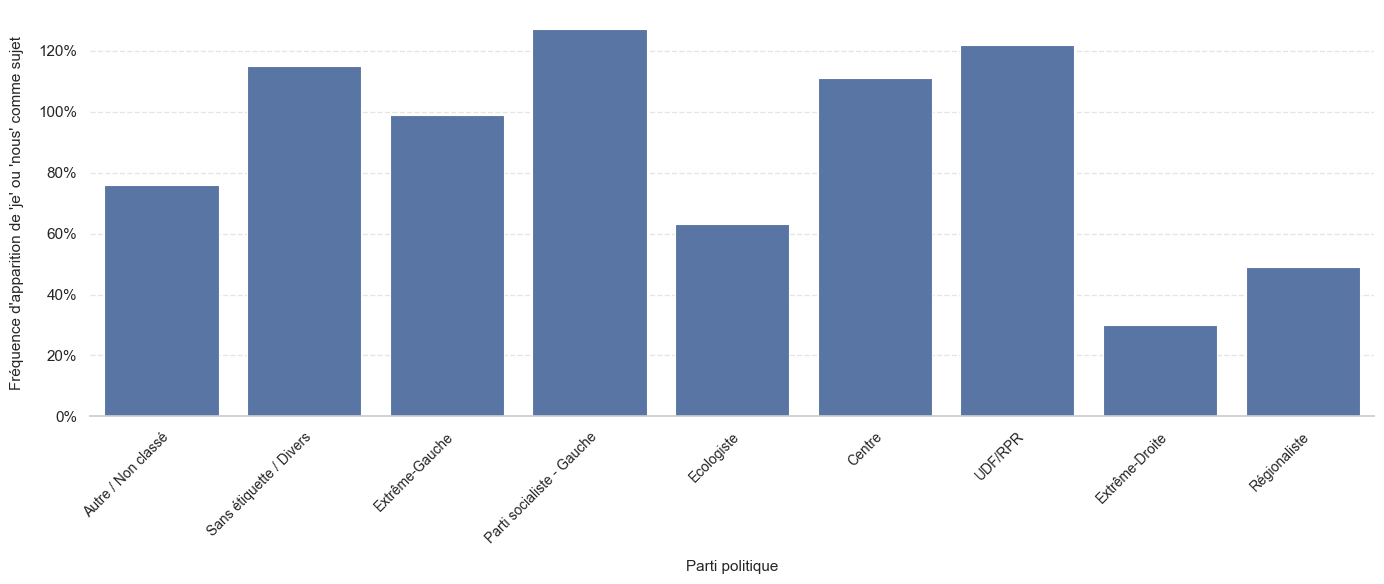

In [ ]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(14, 6))

# Thème
sns.set_theme(style="whitegrid", font_scale=1)
palette = sns.color_palette("Blues_d", n_colors=len(stats))


bars = sns.barplot(
    data = stats,
    x = "parti_synthetique_",
    y = "freq_SUJ",
    edgecolor = "white",
    linewidth = 0.8,
    ax = ax
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.set_xlabel("Parti politique", fontsize=11, labelpad=10)
ax.set_ylabel("Fréquence d'apparition de 'je' ou 'nous' comme sujet", fontsize=11, labelpad=10)

# xticks bien placés et lisibles
ax.set_xticks(range(len(stats)))
ax.set_xticklabels(
    stats["parti_synthetique_"],
    rotation    = 45,
    ha          = "right",      # alignement à droite pour les labels tournés
    rotation_mode = "anchor",   # pivot sur le point d'ancrage → labels bien centrés sous les barres
    fontsize    = 10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

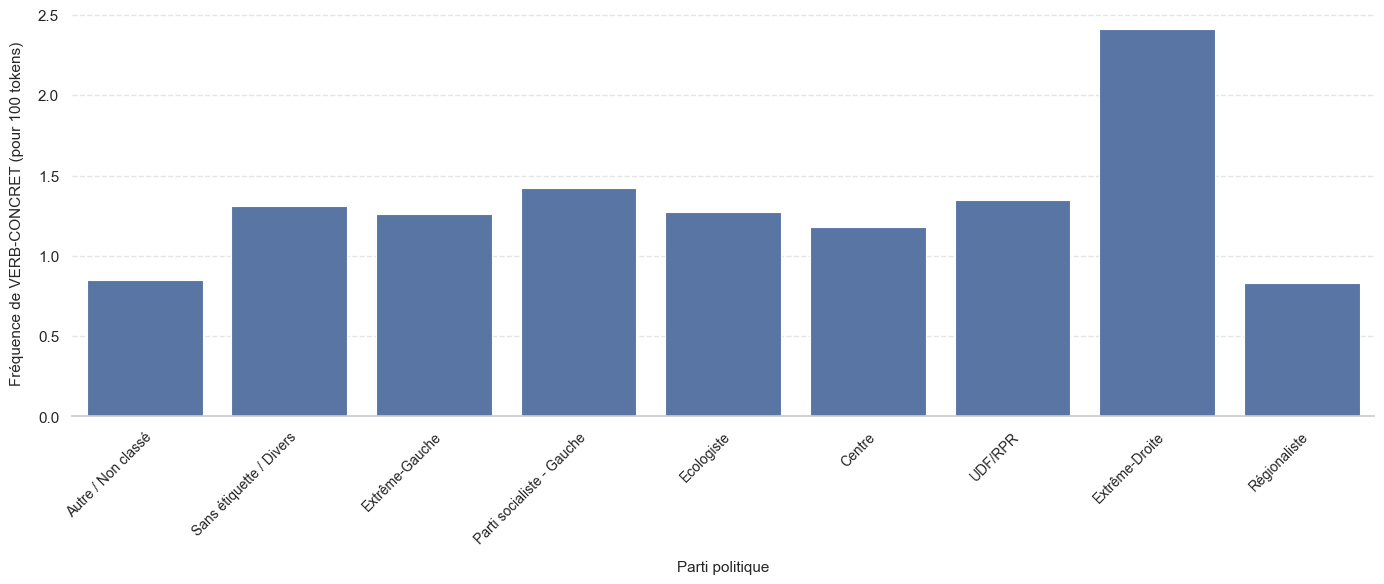

In [56]:
fig, ax = plt.subplots(figsize=(14, 6))

# Thème
sns.set_theme(style="whitegrid", font_scale=1)
palette = sns.color_palette("Blues_d", n_colors=len(stats))


bars = sns.barplot(
    data = stats,
    x = "parti_synthetique_",
    y = "freq_VERB_CONCRET",
    edgecolor = "white",
    linewidth = 0.8,
    ax = ax
)

ax.set_xlabel("Parti politique", fontsize=11, labelpad=10)
ax.set_ylabel("Fréquence de VERB-CONCRET (pour 100 tokens)", fontsize=11, labelpad=10)

# xticks bien placés et lisibles
ax.set_xticks(range(len(stats)))
ax.set_xticklabels(
    stats["parti_synthetique_"],
    rotation    = 45,
    ha          = "right",      # alignement à droite pour les labels tournés
    rotation_mode = "anchor",   # pivot sur le point d'ancrage → labels bien centrés sous les barres
    fontsize    = 10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

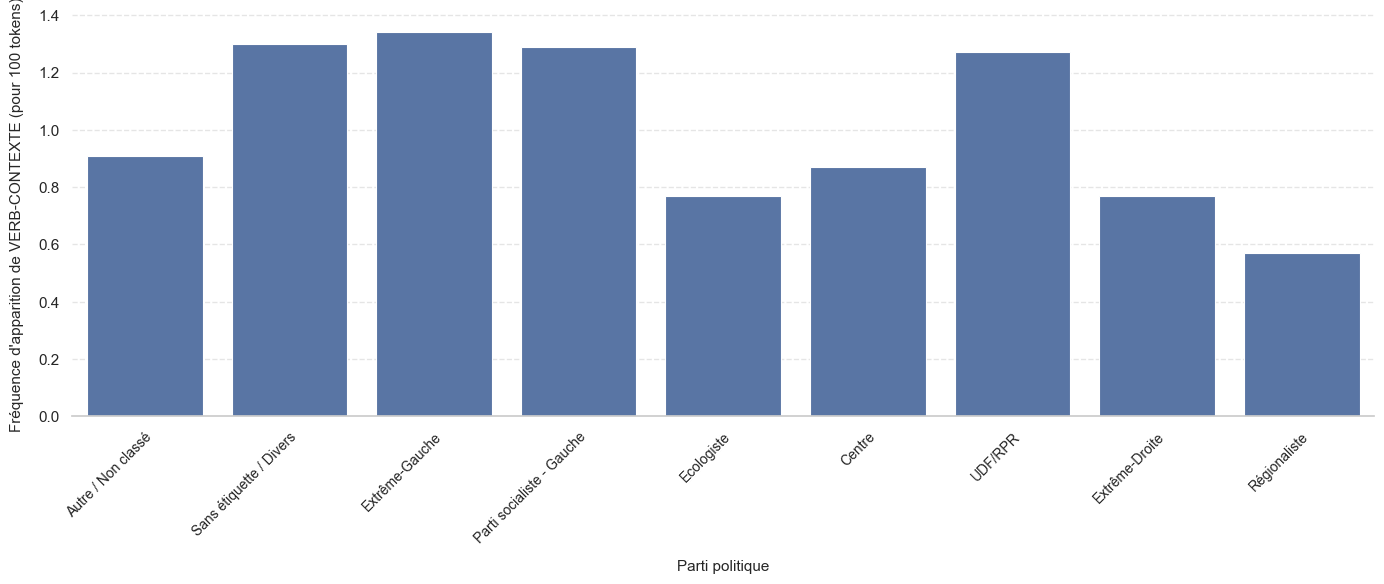

In [55]:
fig, ax = plt.subplots(figsize=(14, 6))

# Thème
sns.set_theme(style="whitegrid", font_scale=1)
palette = sns.color_palette("Blues_d", n_colors=len(stats))


bars = sns.barplot(
    data = stats,
    x = "parti_synthetique_",
    y = "freq_VERB_CONTEXTE",
    edgecolor = "white",
    linewidth = 0.8,
    ax = ax
)

ax.set_xlabel("Parti politique", fontsize=11, labelpad=10)
ax.set_ylabel("Fréquence d'apparition de VERB-CONTEXTE (pour 100 tokens)", fontsize=11, labelpad=10)

# xticks bien placés et lisibles
ax.set_xticks(range(len(stats)))
ax.set_xticklabels(
    stats["parti_synthetique_"],
    rotation    = 45,
    ha          = "right",      # alignement à droite pour les labels tournés
    rotation_mode = "anchor",   # pivot sur le point d'ancrage → labels bien centrés sous les barres
    fontsize    = 10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

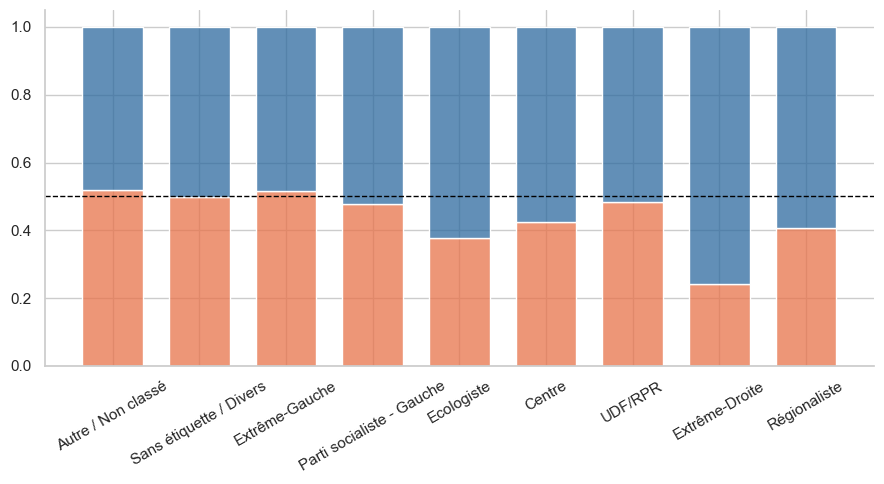

In [54]:

df_long = stats.melt(
    id_vars="parti_synthetique_",
    value_vars=["part_VERB_CONCRET", "part_VERB_CONTEXTE"],
    var_name="type_verbe",
    value_name="part",
)
 
# Barplot empilé
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df_long,
    x="parti_synthetique_",
    weights="part",
    hue="type_verbe",
    multiple="stack",
    palette=["#2D6A9F", "#E8734A"],
    shrink=0.7,
    ax=ax,
    legend=False
)
ax.axhline(0.5, linestyle="--", color="black", linewidth=1)
ax.set(xlabel="", ylabel="", ylim=(0, 1.05))
ax.tick_params(axis="x", rotation=30)
sns.despine()
plt.tight_layout()